In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import zipfile
import os
from PIL import Image  # Import the Image class from the PIL library
from numpy import expand_dims
from numpy import zeros
from numpy import ones
from numpy import vstack
from numpy.random import randn
from numpy.random import randint
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Reshape
from keras.layers import Flatten
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Dropout
from matplotlib import pyplot
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot
from tensorflow.keras.utils import plot_model
import io
from keras.models import load_model

Found 70000 images belonging to 1 classes.


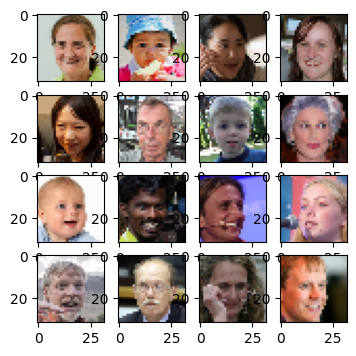

In [6]:
# Specify the zip file containing the images
folder_name = '/content/drive/MyDrive/ffhq.zip'

# Create a ZipFile object
with zipfile.ZipFile(folder_name, 'r') as zip_ref:
    # Extract all contents into a temporary directory
    zip_ref.extractall('images')

# Create an instance of the ImageDataGenerator
data_generator = ImageDataGenerator()

# Load images from the directory using the flow_from_directory() method
data = data_generator.flow_from_directory(
    'images',
    target_size=(32, 32),  # Specify the desired image size
    batch_size=32,         # Specify the batch size
    class_mode='categorical'  # Specify the type of labels (e.g., categorical or binary)
)

# Get a batch of images and labels from the image_data generator
batch_images, batch_labels = next(data)

# Plot the images
pyplot.figure(figsize=(4, 4))
for i in range(16):
    # Define subplot
    pyplot.subplot(4, 4, 1 + i)
    # Turn off axis
    pyplot.axis('on')
    # Plot raw pixel data
    pyplot.imshow(batch_images[i].astype('uint8'))
pyplot.show()


In [7]:
# define the standalone discriminator model
def define_discriminator(in_shape=(32,32,3)):
 model = Sequential()
 # normal
 model.add(Conv2D(64, (3,3), padding='same', input_shape=in_shape))
 model.add(LeakyReLU(alpha=0.2))
 # downsample
 model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
 model.add(LeakyReLU(alpha=0.2))
 # downsample
 model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
 model.add(LeakyReLU(alpha=0.2))
 # downsample
 model.add(Conv2D(256, (3,3), strides=(2,2), padding='same'))
 model.add(LeakyReLU(alpha=0.2))
 # classifier
 model.add(Flatten())
 model.add(Dropout(0.4))
 model.add(Dense(1, activation='sigmoid'))
 # compile model
 opt = Adam(beta_1=0.5)
 model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
 return model
 # define model
model = define_discriminator()
# summarize the model
model.summary()
# plot the model
plot_model(model, to_file='discriminator_plot.png', show_shapes=True, show_layer_names=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        1792      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 128)         147584    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 4, 4, 256)         2

In [8]:
# define the standalone generator model
def define_generator(latent_dim):
 model = Sequential()
 # foundation for 4x4 image
 n_nodes = 256 * 4 * 4
 model.add(Dense(n_nodes, input_dim=latent_dim))
 model.add(LeakyReLU(alpha=0.2))
 model.add(Reshape((4, 4, 256)))
 # upsample to 8x8
 model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
 model.add(LeakyReLU(alpha=0.2))
 # upsample to 16x16
 model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
 model.add(LeakyReLU(alpha=0.2))
 # upsample to 32x32
 model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
 model.add(LeakyReLU(alpha=0.2))
 # output layer
 model.add(Conv2D(3, (3,3), activation='tanh', padding='same'))
 return model
 # define the size of the latent space
latent_dim = 100
# define the generator model
model = define_generator(latent_dim)
# summarize the model
model.summary()
# plot the model
plot_model(model, to_file='generator_plot.png', show_shapes=True, show_layer_names=True)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 4096)              413696    
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 4096)              0         
                                                                 
 reshape (Reshape)           (None, 4, 4, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 128)         524416    
 anspose)                                                        
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 16, 16, 128)       262272    
 Transpose)                                           

In [9]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model):
 # make weights in the discriminator not trainable
 d_model.trainable = False
 # connect them
 model = Sequential()
 # add generator
 model.add(g_model)
 # add the discriminator
 model.add(d_model)
 # compile model
 opt = Adam(beta_1=0.5)
 model.compile(loss='binary_crossentropy', optimizer=opt)
 return model

In [10]:
def load_real_samples(zip_folder, pic_size=(32, 32)):
    images = []
    with zipfile.ZipFile(zip_folder, 'r') as zip_ref:
        folder = zip_ref.namelist()
        for file_name in folder:
            if not file_name.endswith('/'):  # Skip directories
                try:
                    with zip_ref.open(file_name) as img_file:
                        pic = Image.open(img_file)  # Use Image.open to open the image
                        pic = pic.resize(pic_size)

                        # Convert the image to RGB if it's grayscale
                        if pic.mode != 'RGB':
                            pic = pic.convert('RGB')

                        pic = np.array(pic) / 127.5 - 1.0
                        images.append(pic)
                except:
                    print("Skipping non-image file:", file_name)

    # Convert the list of images to a numpy array
    X = np.array(images)

    # Add some debug information
    print(" pictures:", len(images))
    print("dataset shape:", X.shape)

    return X

pic_file = '/content/drive/MyDrive/ffhq.zip'
data_file = load_real_samples(pic_file, pic_size=(32, 32))



 pictures: 70000
dataset shape: (70000, 32, 32, 3)


In [11]:
# select real samples
def generate_real_samples(dataset, n_samples):
 # choose random instances
 ix = randint(0, dataset.shape[0], n_samples)
 # retrieve selected images
 X = dataset[ix]
 # generate 'real' class labels (1)
 y = ones((n_samples, 1))
 return X, y

In [12]:
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
 # generate points in the latent space
 x_input = randn(latent_dim * n_samples)
 # reshape into a batch of inputs for the network
 x_input = x_input.reshape(n_samples, latent_dim)
 return x_input

In [13]:
# use the generator to generate n fake examples, with class labels
def generate_fake_samples(g_model, latent_dim, n_samples):
 # generate points in latent space
 x_input = generate_latent_points(latent_dim, n_samples)
 # predict outputs
 X = g_model.predict(x_input)
 # create 'fake' class labels (0)
 y = zeros((n_samples, 1))
 return X, y


In [14]:
# create and save a plot of generated images
def save_plot(examples, epoch, n=7):
	# scale from [-1,1] to [0,1]
	examples = (examples + 1) / 2.0
	# plot images
	for i in range(n * n):
		# define subplot
		pyplot.subplot(n, n, 1 + i)
		# turn off axis
		pyplot.axis('off')
		# plot raw pixel data
		pyplot.imshow(examples[i])
	# save plot to file
	filename = 'generated_plot_e%03d.png' % (epoch+1)
	pyplot.savefig(filename)
	pyplot.close()

In [15]:
# evaluate the discriminator, plot generated images, save generator model
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=150):
 # prepare real samples
 X_real, y_real = generate_real_samples(dataset, n_samples)
 # evaluate discriminator on real examples
 _, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
 # prepare fake examples
 x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
 # evaluate discriminator on fake examples
 _, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
 # summarize discriminator performance
 print('>Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real*100, acc_fake*100))
 # save plot
 save_plot(x_fake, epoch)
 # save the generator model tile file
 filename = 'generator_model_%03d.h5' % (epoch+1)
 g_model.save(filename)

In [16]:
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=30, n_batch=514):
    batch_epoc = int(dataset.shape[0] / n_batch)
    half_batch = int(n_batch / 2)
    # manually enumerate epochs
    for i in range(n_epochs):
        # enumerate batches over the training set
        for j in range(batch_epoc):
            # get randomly selected 'real' samples
            X_real, y_real = generate_real_samples(dataset, half_batch)
            # update discriminator model weights
            loss_d_a, _ = d_model.train_on_batch(X_real, y_real)
            if isinstance(loss_d_a, list):
                loss_d_a = loss_d_a[0]
            # generate 'fake' examples
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
            # update discriminator model weights
            loss_d_b, _ = d_model.train_on_batch(X_fake, y_fake)
            if isinstance(loss_d_b, list):
                loss_d_b = loss_d_b[0]
            # prepare points in latent space as input for the generator
            ganX = generate_latent_points(latent_dim, n_batch)
            # create inverted labels for the fake samples
            ganY = ones((n_batch, 1))
            # update the generator via the discriminator's error
            generator_loss = gan_model.train_on_batch(ganX, ganY)
            if isinstance(generator_loss, list):
                generator_loss = generator_loss[0]
            # summarize loss on this batch
            print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
                (i+1, j+1, batch_epoc, loss_d_a, loss_d_b, generator_loss))
        # evaluate model performance every 10 epochs
        if (i+1) % 10 == 0:
            summarize_performance(i, g_model, d_model, dataset, latent_dim)



In [17]:
# size of the latent space
latent_dim = 100
# create the discriminator
d_model = define_discriminator()
# create the generator
g_model = define_generator(latent_dim)
# create the gan
gan_model = define_gan(g_model, d_model)
# load image data
Images = '/content/drive/MyDrive/ffhq.zip'
dataset = load_real_samples(Images)
# train model
train(g_model, d_model, gan_model, dataset, latent_dim)


 pictures: 70000
dataset shape: (70000, 32, 32, 3)
9/9 [==============================] - 0s 27ms/step
>1, 1/136, d1=0.694, d2=0.708 g=0.690
9/9 [==============================] - 0s 25ms/step
>1, 2/136, d1=0.432, d2=0.831 g=0.644
9/9 [==============================] - 0s 24ms/step
>1, 3/136, d1=0.139, d2=1.268 g=0.725
9/9 [==============================] - 0s 24ms/step
>1, 4/136, d1=0.099, d2=0.604 g=1.290
9/9 [==============================] - 0s 24ms/step
>1, 5/136, d1=0.069, d2=0.577 g=1.179
9/9 [==============================] - 0s 24ms/step
>1, 6/136, d1=0.030, d2=0.588 g=1.031
9/9 [==============================] - 0s 23ms/step
>1, 7/136, d1=0.035, d2=0.503 g=1.186
9/9 [==============================] - 0s 24ms/step
>1, 8/136, d1=0.022, d2=0.675 g=1.368
9/9 [==============================] - 0s 25ms/step
>1, 9/136, d1=0.008, d2=1.461 g=1.763
9/9 [==============================] - 0s 24ms/step
>1, 10/136, d1=0.029, d2=0.584 g=1.674
9/9 [==============================] - 0s 25ms/s

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


9/9 [==============================] - 0s 21ms/step
>11, 1/136, d1=0.732, d2=0.511 g=1.539
9/9 [==============================] - 0s 22ms/step
>11, 2/136, d1=0.655, d2=0.619 g=1.487
9/9 [==============================] - 0s 21ms/step
>11, 3/136, d1=0.623, d2=0.570 g=1.608
9/9 [==============================] - 0s 21ms/step
>11, 4/136, d1=0.672, d2=0.578 g=1.625
9/9 [==============================] - 0s 25ms/step
>11, 5/136, d1=0.628, d2=0.544 g=1.568
9/9 [==============================] - 0s 22ms/step
>11, 6/136, d1=0.603, d2=0.636 g=1.544
9/9 [==============================] - 0s 22ms/step
>11, 7/136, d1=0.595, d2=0.589 g=1.609
9/9 [==============================] - 0s 21ms/step
>11, 8/136, d1=0.675, d2=0.555 g=1.468
9/9 [==============================] - 0s 20ms/step
>11, 9/136, d1=0.623, d2=0.710 g=1.393
9/9 [==============================] - 0s 22ms/step
>11, 10/136, d1=0.581, d2=0.685 g=1.531
9/9 [==============================] - 0s 20ms/step
>11, 11/136, d1=0.550, d2=0.503 g=1.6

9/9 [==============================] - 0s 23ms/step
>21, 1/136, d1=0.616, d2=0.634 g=1.112
9/9 [==============================] - 0s 25ms/step
>21, 2/136, d1=0.628, d2=0.608 g=1.117
9/9 [==============================] - 0s 22ms/step
>21, 3/136, d1=0.610, d2=0.659 g=1.143
9/9 [==============================] - 0s 21ms/step
>21, 4/136, d1=0.610, d2=0.683 g=1.143
9/9 [==============================] - 0s 21ms/step
>21, 5/136, d1=0.634, d2=0.641 g=1.223
9/9 [==============================] - 0s 21ms/step
>21, 6/136, d1=0.735, d2=0.580 g=1.187
9/9 [==============================] - 0s 22ms/step
>21, 7/136, d1=0.690, d2=0.605 g=1.195
9/9 [==============================] - 0s 23ms/step
>21, 8/136, d1=0.732, d2=0.632 g=1.221
9/9 [==============================] - 0s 20ms/step
>21, 9/136, d1=0.662, d2=0.693 g=1.245
9/9 [==============================] - 0s 22ms/step
>21, 10/136, d1=0.654, d2=0.657 g=1.150
9/9 [==============================] - 0s 22ms/step
>21, 11/136, d1=0.679, d2=0.626 g=1.1

4/4 [==============================] - 0s 21ms/step


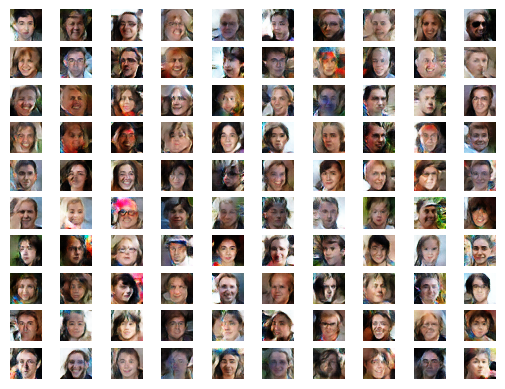

In [19]:
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
	# generate points in the latent space
	x_input = randn(latent_dim * n_samples)
	# reshape into a batch of inputs for the network
	x_input = x_input.reshape(n_samples, latent_dim)
	return x_input

# plot the generated images
def create_plot(examples, n):
	# plot images
	for i in range(n * n):
		# define subplot
		pyplot.subplot(n, n, 1 + i)
		# turn off axis
		pyplot.axis('off')
		# plot raw pixel data
		pyplot.imshow(examples[i, :, :])
	pyplot.show()

# load model
model = load_model('/content/generator_model_030.h5')
# generate images
latent_points = generate_latent_points(100, 100)
# generate images
X = model.predict(latent_points)
# scale from [-1,1] to [0,1]
X = (X + 1) / 2.0
# plot the result
create_plot(X, 10)